# Notebook 04. Producto cartográfico final

A partir de la capa vectorial clasificada en el notebook 03, este notebook genera los productos finales de la prueba: un GeoTIFF con la probabilidad continua de asentamiento informal por celda, un GeoPackage con la clasificación en cuatro niveles, un GeoJSON simplificado pensado para uso web, y dos mapas estáticos en PDF y PNG (uno con la probabilidad continua y otro con la clasificación discreta), ambos con leyenda, escala, contexto cartográfico CartoDB Positron y un disclaimer explícito sobre la naturaleza preliminar del producto.


## 0. Setup

In [1]:
import sys
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

from src.config import (
    DATA_RAW, DATA_PROC, OUTPUTS_RESULTS, OUTPUTS_MAPS, CRS_TRABAJO,
    PERIMETRO_URBANO_SHP,
)
from src.viz import (
    rasterizar_gdf, guardar_geotiff, colormap_probabilidad, colormap_clases,
)

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
try:
    from matplotlib_scalebar.scalebar import ScaleBar
    HAS_SCALEBAR = True
except ImportError:
    HAS_SCALEBAR = False
try:
    import contextily as cx
    HAS_CTX = True
except ImportError:
    HAS_CTX = False

## 1. Cargar capa clasificada

In [2]:
gdf = gpd.read_file(OUTPUTS_RESULTS / "asentamientos_informales_clasificado.gpkg")
print(f"Capa clasificada: {len(gdf):,} celdas")
print(gdf["clase_probabilidad"].value_counts())

Capa clasificada: 8,902 celdas
clase_probabilidad
Baja        4391
Media       2291
Alta        1391
Muy alta     829
Name: count, dtype: int64


## 2. Exportar GeoTIFF de probabilidad continua

In [3]:
arr_prob, transform, crs = rasterizar_gdf(gdf, "prob_informal", resolucion_m=100)
out_tif = OUTPUTS_RESULTS / "probabilidad_asentamientos_informales_cartagena.tif"
guardar_geotiff(arr_prob, transform, crs, out_tif)
print(f"(Ok) GeoTIFF guardado: {out_tif}")

(Ok) GeoTIFF guardado: /Users/transformaciondigita/PERSONALES/onu-habitat/entrevista-onu-habitat/prueba-tecnica-cartagena/outputs/results/probabilidad_asentamientos_informales_cartagena.tif


## 3. Mapa estático principal

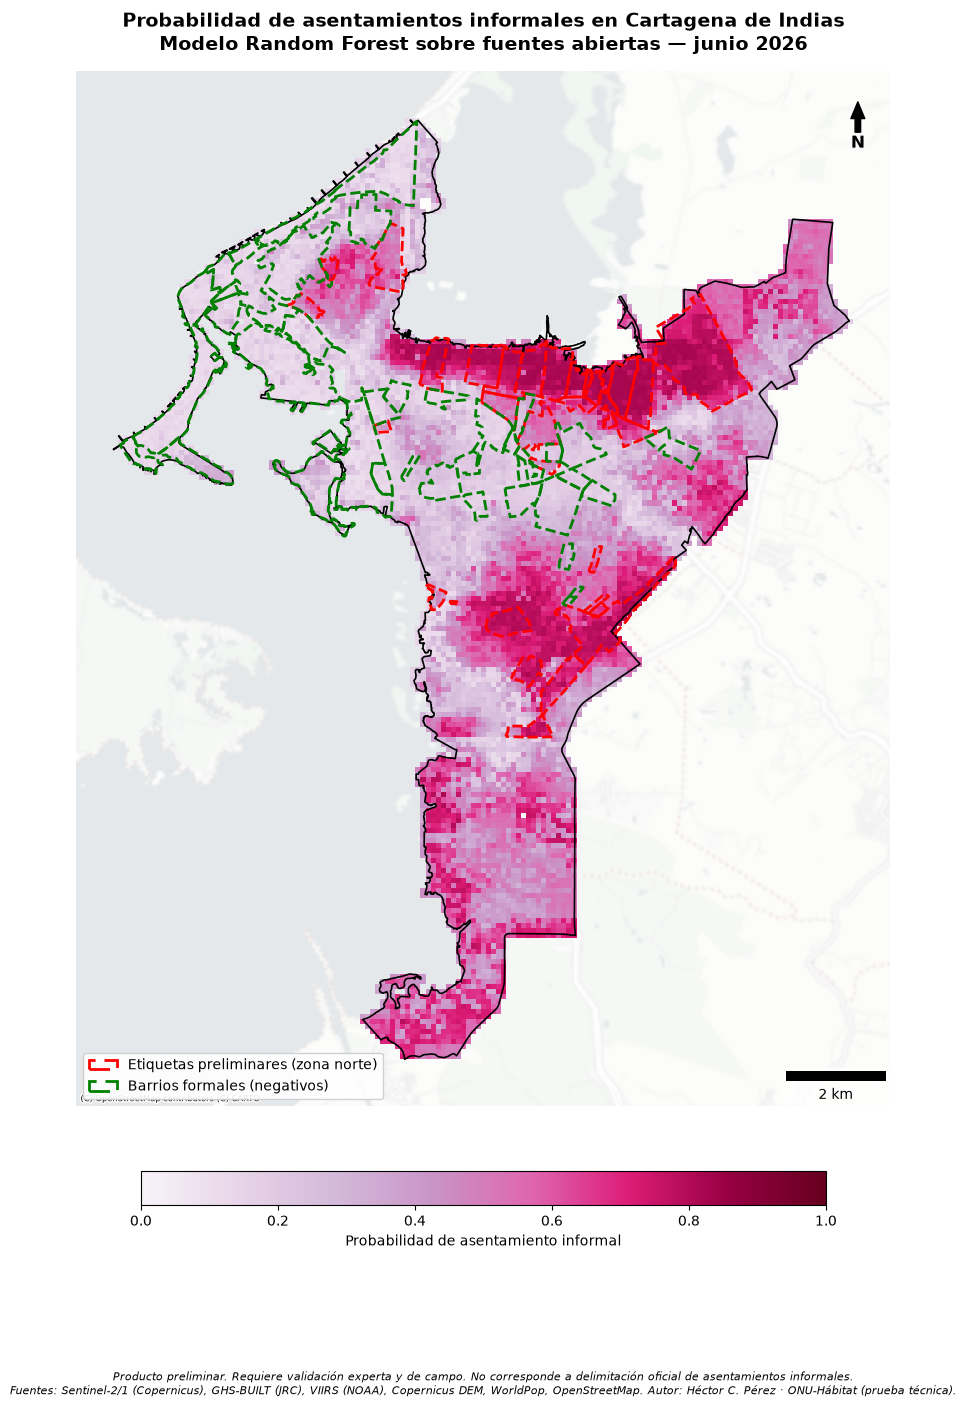

(ok) Mapa final guardado en /Users/transformaciondigita/PERSONALES/onu-habitat/entrevista-onu-habitat/prueba-tecnica-cartagena/outputs/maps


In [4]:
fig, ax = plt.subplots(figsize=(14, 14))

# Plot principal: probabilidad de informalidad
gdf.plot(
    column="prob_informal",
    cmap=colormap_probabilidad(),
    ax=ax,
    legend=True,
    legend_kwds={
        "label": "Probabilidad de asentamiento informal",
        "shrink": 0.5,
        "orientation": "horizontal",
        "pad": 0.05,
    },
    vmin=0, vmax=1,
    edgecolor="none",
)

# Cargar perímetro urbano oficial DANE y etiquetas para contexto
perimetro = gpd.read_file(PERIMETRO_URBANO_SHP).to_crs(CRS_TRABAJO)
perimetro.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.2)

# Positivos preliminares
positivos = gpd.read_file(DATA_RAW / "etiquetas_positivas_zona_norte.gpkg").to_crs(CRS_TRABAJO)
positivos.plot(ax=ax, facecolor="none", edgecolor="red",
               linewidth=2, linestyle="--", label="Etiquetas preliminares (zona norte)")

# Negativos
negativos = gpd.read_file(DATA_RAW / "etiquetas_negativas_barrios_formales.gpkg").to_crs(CRS_TRABAJO)
negativos.plot(ax=ax, facecolor="none", edgecolor="green",
               linewidth=2, linestyle="--", label="Barrios formales (negativos)")

# Basemap si está disponible
if HAS_CTX:
    try:
        cx.add_basemap(ax, crs=CRS_TRABAJO, source=cx.providers.CartoDB.PositronNoLabels,
                       attribution_size=6, alpha=0.6)
    except Exception as e:
        print(f"⚠ Basemap no agregado: {e}")

ax.set_title(
    "Probabilidad de asentamientos informales en Cartagena de Indias\n"
    "Modelo Random Forest sobre fuentes abiertas — junio 2026",
    fontsize=14, fontweight="bold", pad=15,
)
ax.set_axis_off()

# Escala (opcional)
if HAS_SCALEBAR:
    try:
        ax.add_artist(ScaleBar(1, units="m", location="lower right", box_alpha=0.7))
    except Exception:
        pass

# Norte (simple)
ax.annotate("N", xy=(0.96, 0.97), xytext=(0.96, 0.93),
            arrowprops=dict(facecolor="black", width=4, headwidth=10),
            ha="center", va="center",
            xycoords="axes fraction", fontsize=12, fontweight="bold")

# Leyenda manual con las clases
ax.legend(loc="lower left", fontsize=10, framealpha=0.9)

# Disclaimer
disclaimer = (
    "Producto preliminar. Requiere validación experta y de campo. "
    "No corresponde a delimitación oficial de asentamientos informales.\n"
    "Fuentes: Sentinel-2/1 (Copernicus), GHS-BUILT (JRC), VIIRS (NOAA), Copernicus DEM, "
    "WorldPop, OpenStreetMap. Autor: Héctor C. Pérez · ONU-Hábitat (prueba técnica)."
)
fig.text(0.5, -0.01, disclaimer, ha="center", fontsize=8, style="italic", wrap=True)

plt.tight_layout()
fig.savefig(OUTPUTS_MAPS / "mapa_final.pdf", bbox_inches="tight", dpi=200)
fig.savefig(OUTPUTS_MAPS / "mapa_final.png", bbox_inches="tight", dpi=200)
plt.show()
print(f"(ok) Mapa final guardado en {OUTPUTS_MAPS}")

## 4. Mapa de clasificación discreta (4 clases)

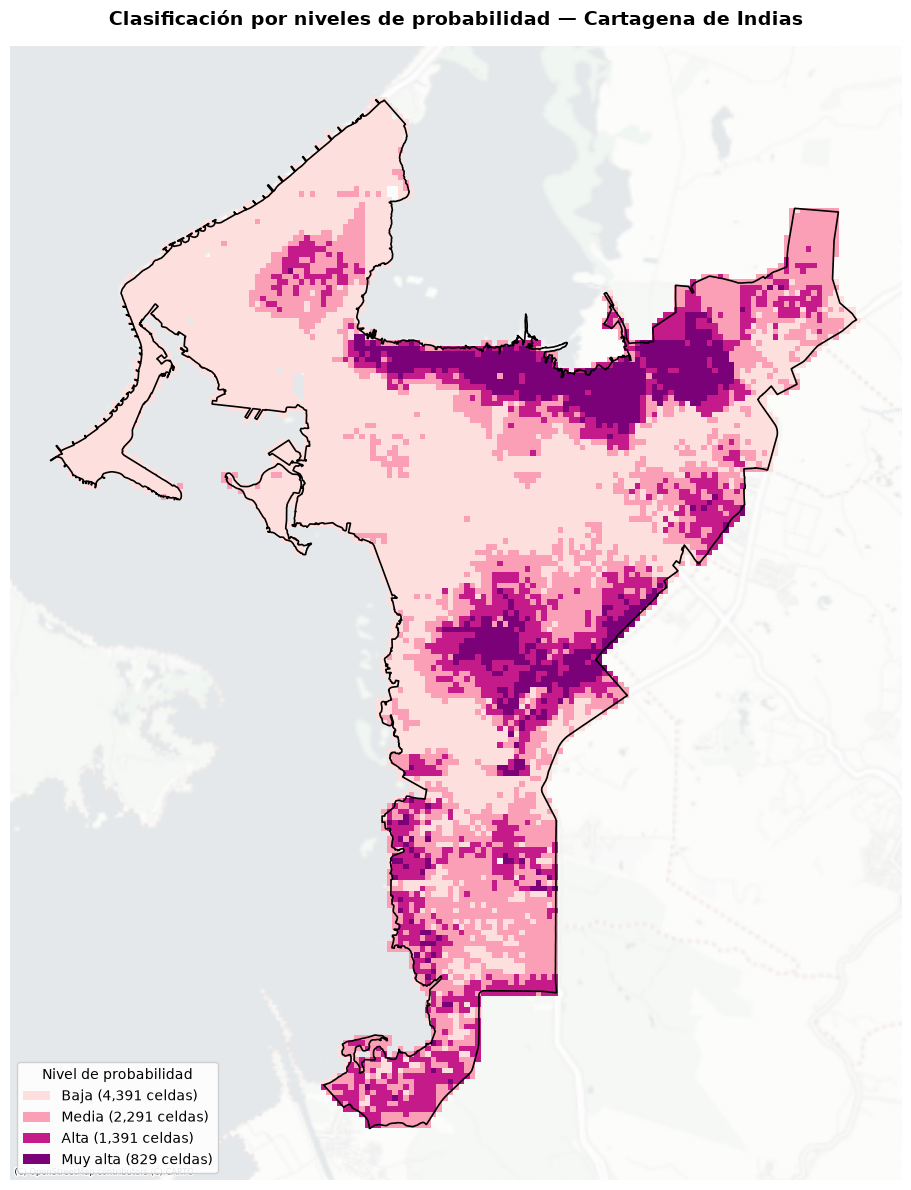

In [5]:
fig, ax = plt.subplots(figsize=(12, 12))
colores = colormap_clases()
for clase, color in colores.items():
    sub = gdf[gdf["clase_probabilidad"] == clase]
    if len(sub) > 0:
        sub.plot(ax=ax, color=color, edgecolor="none", label=f"{clase} ({len(sub):,} celdas)")

perimetro.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.2)
if HAS_CTX:
    try:
        cx.add_basemap(ax, crs=CRS_TRABAJO, source=cx.providers.CartoDB.PositronNoLabels,
                       attribution_size=6, alpha=0.6)
    except Exception:
        pass

ax.set_title(
    "Clasificación por niveles de probabilidad — Cartagena de Indias",
    fontsize=14, fontweight="bold", pad=15,
)
ax.set_axis_off()
ax.legend(loc="lower left", fontsize=10, title="Nivel de probabilidad", framealpha=0.9)
plt.tight_layout()
fig.savefig(OUTPUTS_MAPS / "mapa_clases.pdf", bbox_inches="tight", dpi=200)
fig.savefig(OUTPUTS_MAPS / "mapa_clases.png", bbox_inches="tight", dpi=200)
plt.show()

## 5. Resumen estadístico

In [6]:
print("\nResumen del producto final")
print("-" * 60)
print(f"Total celdas analizadas: {len(gdf):,}")
print(f"Área cubierta: {len(gdf) * 100 * 100 / 1e6:.1f} km²\n")
print("Distribución por clase:")
distr = gdf["clase_probabilidad"].value_counts()
for clase in ["Baja", "Media", "Alta", "Muy alta"]:
    n = distr.get(clase, 0)
    pct = 100 * n / len(gdf)
    area_km2 = n * 100 * 100 / 1e6
    print(f"  {clase:<10} {n:>6,} celdas  ({pct:5.1f}%)  → {area_km2:>6.1f} km²")

print(f"\nProbabilidad media:    {gdf['prob_informal'].mean():.3f}")
print(f"Probabilidad mediana:  {gdf['prob_informal'].median():.3f}")
print(f"Celdas con prob > 0.5: {(gdf['prob_informal'] > 0.5).sum():,}")


Resumen del producto final
------------------------------------------------------------
Total celdas analizadas: 8,902
Área cubierta: 89.0 km²

Distribución por clase:
  Baja        4,391 celdas  ( 49.3%)  →   43.9 km²
  Media       2,291 celdas  ( 25.7%)  →   22.9 km²
  Alta        1,391 celdas  ( 15.6%)  →   13.9 km²
  Muy alta      829 celdas  (  9.3%)  →    8.3 km²

Probabilidad media:    0.418
Probabilidad mediana:  0.405
Celdas con prob > 0.5: 3,343


## 6. Exportar también GeoJSON simplificado (opcional, para web)

In [7]:
gdf_simplified = gdf.copy()
gdf_simplified["geometry"] = gdf_simplified.geometry.simplify(tolerance=5)
gdf_simplified_4326 = gdf_simplified.to_crs("EPSG:4326")
gdf_simplified_4326.to_file(OUTPUTS_RESULTS / "asentamientos_informales_cartagena.geojson",
                             driver="GeoJSON")
print(f"(ok) GeoJSON exportado")

(ok) GeoJSON exportado


---
## Producto cartográfico completado

Listado de productos generados:

- `outputs/results/probabilidad_asentamientos_informales_cartagena.tif`
- `outputs/results/asentamientos_informales_clasificado.gpkg`
- `outputs/results/asentamientos_informales_cartagena.geojson`
- `outputs/maps/mapa_final.pdf` (+ `.png`)
- `outputs/maps/mapa_clases.pdf` (+ `.png`)
- `outputs/maps/fig_feature_importance.png`
- `outputs/maps/fig_roc_pr.png`